# **Projeto de Regressão Linear Multipla:**
## `Estimativa sobre expectativa de vida`
### Nosso objetivo é construir um modelo de regressão que faça a estimativa da expectativa de vida

---
### Primeira Parte: Análise e Preparação de Dados

#### Imports

In [1]:
# import sys
# !{sys.executable} -m pip install plotly

In [2]:
# Importando os módulos
import numpy as np              
import pandas as pd             # Manipulação e análise de dados em DataFrames
import matplotlib.pyplot as plt # Criação de gráficos
import seaborn as sns           # Biblioteca de visualização baseada em matplotlib
import plotly.express as px     # Visualizações interativas

# Sklearn (biblioteca de Machine Learning)
from sklearn.preprocessing import StandardScaler   # Padronização/normalização de variáveis (escala média=0 e desvio=1)
from sklearn.model_selection import train_test_split, GridSearchCV  # Dividir dados treino/teste e otimizar hiperparâmetros
from sklearn.linear_model import LinearRegression  # Modelo de regressão linear
from sklearn.neighbors import KNeighborsRegressor  # Modelo de regressão baseado em K-vizinhos mais próximos
from sklearn.tree import DecisionTreeRegressor     # Modelo de regressão baseado em árvore de decisão
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # Modelos ensemble (combinação de várias árvores)
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error # Métricas para avaliar modelos de regressão
from sklearn.feature_selection import RFE          # Seleção de variáveis mais importantes (Recursive Feature Elimination)
from sklearn.impute import KNNImputer              # Imputação de valores ausentes usando K-Nearest Neighbors

import warnings
warnings.filterwarnings('ignore') # Oculta warnings do Python

In [3]:
# Importando o arquivo csv

dados = pd.read_csv('dataset.csv')

In [4]:
dados.shape

(2938, 22)

In [5]:
# Amostra Aleatória dos dados

dados.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
351,Botswana,2000,Developing,47.8,647.0,2,5.37,250.891648,86.0,2672,...,97.0,4.64,97.0,38.8,3349.688230,172834.0,12.3,12.2,0.559,11.7
2742,Ukraine,2003,Developing,67.6,256.0,6,5.92,21.223864,77.0,411,...,99.0,6.93,97.0,0.9,148.522488,4781295.0,2.8,2.9,0.691,14.3
90,Argentina,2005,Developing,74.9,127.0,11,7.53,96.166534,88.0,0,...,95.0,6.85,98.0,0.1,576.883829,39145488.0,1.1,1.0,0.780,16.3
29,Albania,2002,Developing,73.3,15.0,1,3.73,104.516916,96.0,16,...,98.0,6.30,98.0,0.1,1453.642777,3511.0,2.0,2.1,0.670,10.7
975,Gambia,2002,Developing,56.6,298.0,3,2.08,0.000000,92.0,32,...,86.0,3.75,87.0,2.5,NaN,NaN,9.8,9.8,0.392,7.0
1533,Lithuania,2004,Developed,71.6,24.0,0,12.10,76.361877,94.0,1,...,9.0,5.67,94.0,0.1,676.966998,337775.0,3.1,3.1,0.792,16.3
431,Burundi,2000,Developing,58.0,386.0,25,6.61,9.696689,NaN,18363,...,71.0,4.98,8.0,5.2,135.998446,6476.0,9.0,8.9,0.268,4.5
1552,Luxembourg,2001,Developed,78.0,96.0,0,12.89,7877.336560,86.0,0,...,99.0,7.40,99.0,0.1,48179.428500,441525.0,1.0,1.0,0.854,13.4
2695,Turkey,2001,Developing,78.0,14.0,41,1.49,256.434175,77.0,30509,...,88.0,5.16,88.0,0.1,3119.637160,64191474.0,5.2,5.1,0.653,11.1
2520,Sweden,2000,Developed,79.6,73.0,0,6.20,3689.727300,NaN,59,...,99.0,8.18,99.0,0.1,29283.550000,887219.0,1.4,1.3,0.873,15.9


In [6]:
# Tipo dos dados e colunas NaN

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

#### **Algumas colunas estão com espaços no nome!**

In [7]:
# Removendo os espaços nas colunas, deixando tudo em minusculo com somente a primeira letra maiuscula e colocando _ nos nomes

dados.columns = (
    dados.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.capitalize()
)

In [8]:
# Resultado

dados.head()

,Country,Year,Status,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Percentage_expenditure,Hepatitis_b,Measles,...,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


**Na fonte de dados não esta muito claro o que essas variaveis representam (Percentage_expenditure, under-five_deaths, Income_composition_of_resources), então vamos remove-las da analise**

In [9]:
dados = dados.drop(columns=[
    "Percentage_expenditure",
    "Under-five_deaths",
    "Income_composition_of_resources"
])

In [10]:
# Ficaram 19 Colunas

dados.shape

(2938, 19)

#### Visualização das colunas

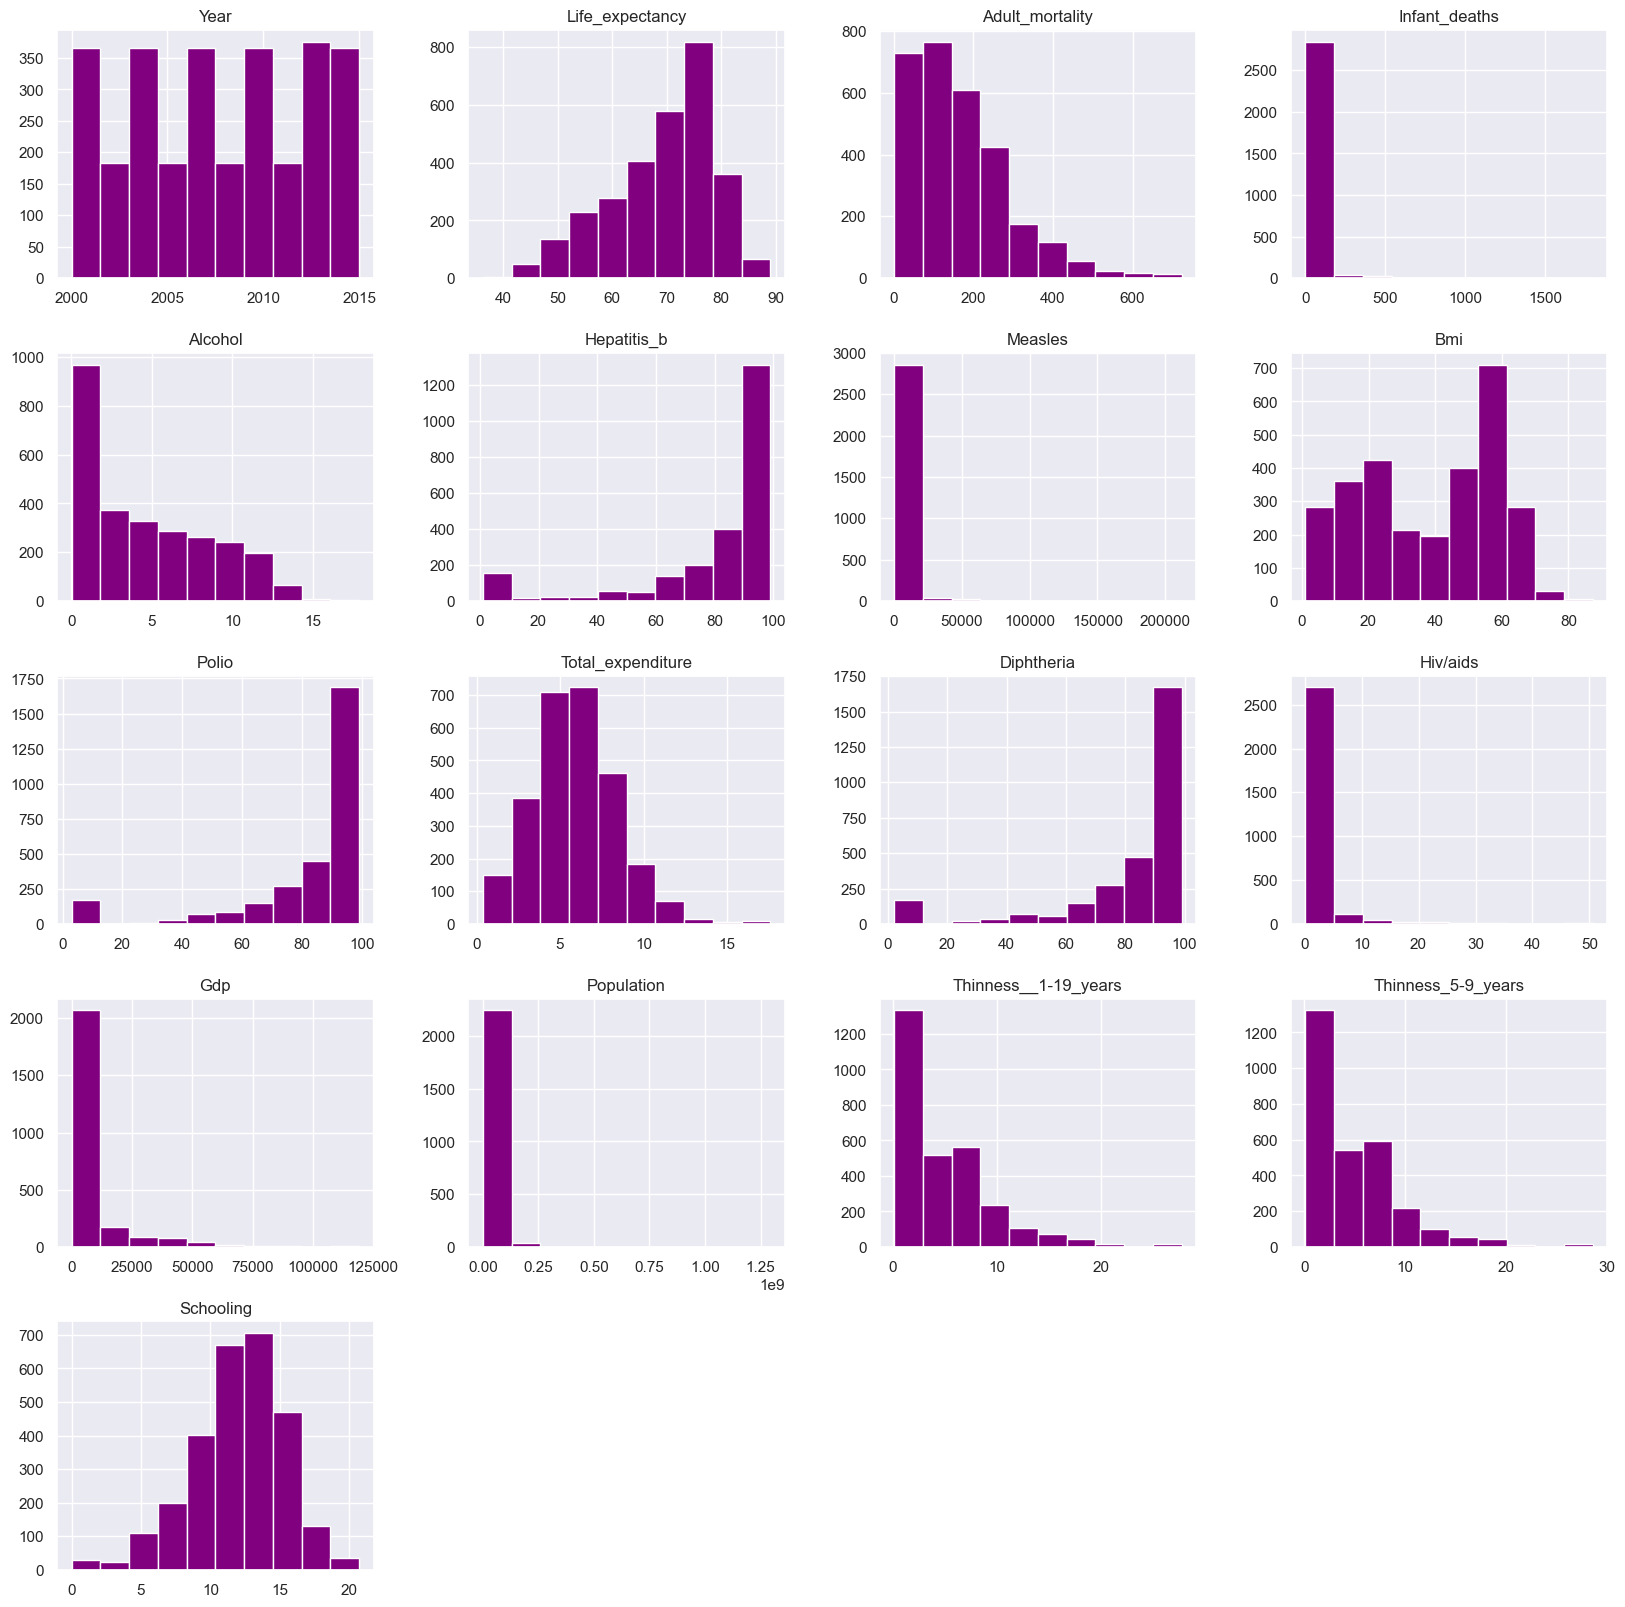

In [11]:
# set definindo a configuração do grafico
# style='darkgrid' - fundo cinza e com grid
# rc (runtime configuration) figure.figsize':(20,20) - definindo o tamanho padrão da figura.
# hist() histogramas para todas as colunas numéricas

sns.set(style='darkgrid', rc={'figure.figsize':(20,20)})

dados.hist(color='purple');

#### Construindo o Dicionário de Dados

In [12]:
# Criando um dicionário com a descrição de cada variável

df_dict = {
    "country": "País de origem dos dados.",
    "life_expectancy": "Expectativa de vida ao nascer, em anos.",
    "year": "Ano em que os dados foram coletados.",
    "status": "Status de desenvolvimento do país ('Developing' para países em desenvolvimento, 'Developed' para país",
    "adult_mortality": "Taxa de mortalidade de adultos entre 15 e 60 anos por 1000 habitantes.",
    "inf_death": "Número de mortes de crianças com menos de 5 anos por 1000 nascidos vivos.",
    "alcohol": "Consumo de álcool per capita (litros de álcool puro por ano).",
    "hepatitisB": "Cobertura de vacinação contra hepatite B em crianças de 1 ano (%).",
    "measles": "Número de casos de sarampo relatados por 1000 habitantes.",
    "bmi": "Índice médio de massa corporal da população adulta.",
    "polio": "Cobertura de vacinação contra poliomielite em crianças de 1 ano (%).",
    "diphtheria": "Cobertura de vacinação contra difteria, tétano e coqueluche (DTP3) em crianças de 1 ano (%).",
    "hiv": "Prevalência de HIV na população adulta (%).",
    "gdp": "Produto Interno Bruto per capita (em dólares americanos).",
    "total_expenditure": "Gasto total em saúde como porcentagem do PIB.",
    "thinness_till19": "Prevalência de magreza em crianças e adolescentes de 10 a 19 anos (%).",
    "thinness_till9": "Prevalência de magreza em crianças de 5 a 9 anos (%).",
    "school": "Número médio de anos de escolaridade.",
    "population": "População total do país."
}

In [13]:
# Consultando significado de life_expectancy

df_dict['life_expectancy']

'Expectativa de vida ao nascer, em anos.'

#### Análise Exploratória

* **Variavel Alvo** = ***`Life_expectancy`***

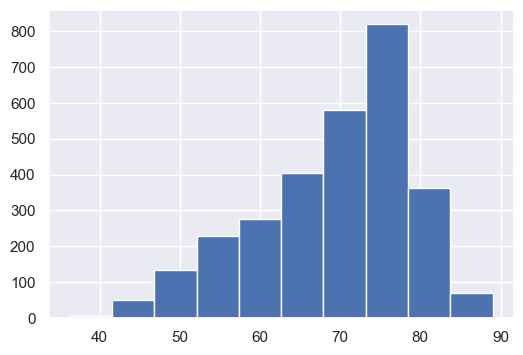

In [14]:
plt.figure(figsize=(6,4))

dados['Life_expectancy'].hist()

plt.show()

**A Maioria dos registro é entre 60 e 80 anos!**

In [15]:
# Resumo estatistico das variaveis numericas

dados.describe()

,Year,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Hepatitis_b,Measles,Bmi,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,87.300000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,20.700000


In [16]:
# Resumo estatistico das variaveis categorica

dados.describe(include=['object'])

,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [17]:
# Verificando o significado de Status no dicionário de dados

df_dict['status']

"Status de desenvolvimento do país ('Developing' para países em desenvolvimento, 'Developed' para país"

In [18]:
df_dict['country']

'País de origem dos dados.'

In [19]:
# Quantidade de países Desenvolvidos ou Em desenvolvimento

dados.Status.value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

#### Correlação com a variavel alvo

In [20]:
# Selecionando algumas colunas para analise de correlação

dados[['Life_expectancy',
       'Population',
       'Hepatitis_b',
       'Gdp',
       'Total_expenditure',
       'Alcohol',
       'Schooling']].corr()['Life_expectancy']

Life_expectancy      1.000000
Population          -0.021538
Hepatitis_b          0.256762
Gdp                  0.461455
Total_expenditure    0.218086
Alcohol              0.404877
Schooling            0.751975
Name: Life_expectancy, dtype: float64

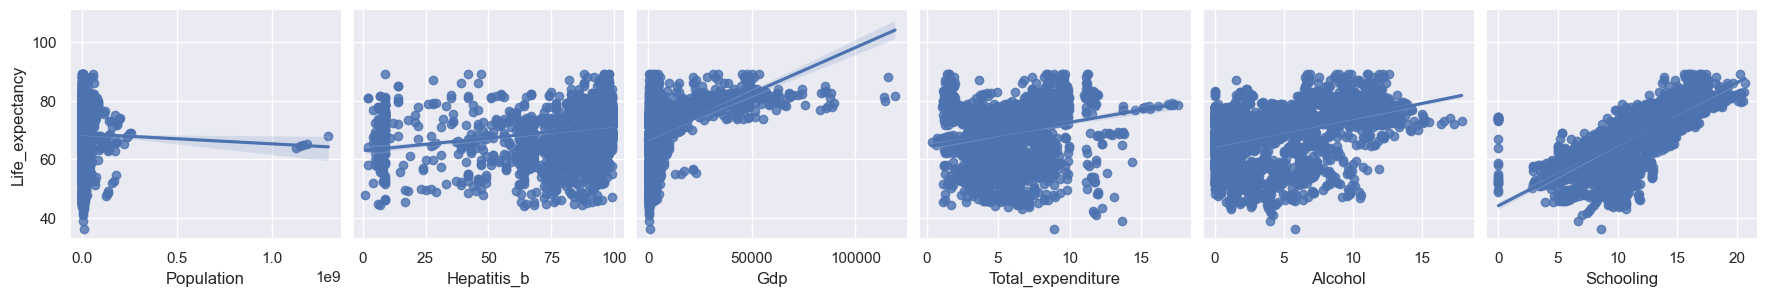

In [21]:
# Visualizando a correlação entre as variaveis com a variavel alvo

import seaborn as sns

linha = [
    'Population',
    'Hepatitis_b',
    'Gdp',
    'Total_expenditure',
    'Alcohol',
    'Schooling'
]

alvo = ['Life_expectancy']

sns.pairplot(
    dados,
    x_vars=linha,
    y_vars=alvo,
    kind='reg',
    height=3
)

* **População:** Apresenta correlação negativa com a expectativa de vida, países com maior população tendem a apresentar valores menores de expectativa de vida, porém a presença de outliers pode estar influenciando essa relação.
  
* **Hepatite B:** Maior cobertura vacinal está associada a maior expectativa de vida, indicando impacto positivo das políticas de imunização.

* **GDP (PIB):** Países com maior PIB tendem a apresentar maior expectativa de vida, refletindo melhores condições socioeconômicas.

* **Gasto total com saúde:** Existe correlação positiva, sugerindo que maiores investimentos em saúde contribuem para maior longevidade.

* **Escolaridade:** Maior nível educacional está fortemente associado ao aumento da expectativa de vida.

* **Álcool:** Esse resultado pode estar associado a fatores socioeconômicos — países mais desenvolvidos tendem a registrar tanto maior expectativa de vida quanto maior consumo de álcool, o que pode gerar uma correlação espúria.

#### Relação de mortalidade em adultos e expectativa de vida

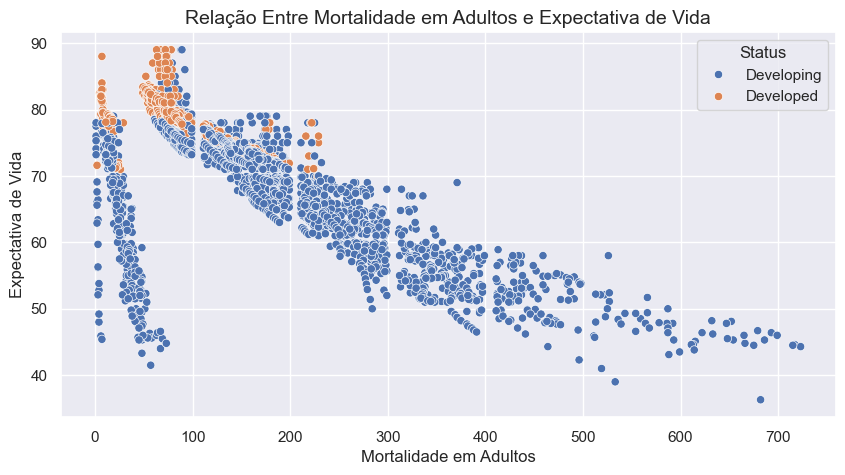

In [22]:
# Relação de mortalidade em adultos e expectativa de vida

plt.figure(figsize=(10,5))

sns.scatterplot(x='Adult_mortality',y='Life_expectancy',data=dados, hue='Status')

plt.title('Relação Entre Mortalidade em Adultos e Expectativa de Vida',fontsize=14)
plt.xlabel('Mortalidade em Adultos')
plt.ylabel('Expectativa de Vida');

**Podemos ver que mortalidade em adultos e a expectativa de vida tem uma certa relação, o interessante é que os países desenvolvidos neste dataset tem uma tendecia de ter as maiores expectativas de vida, apesa de serem poucos, como melhor mostra no grafico abaixo.**

<Axes: xlabel='Status', ylabel='Count'>

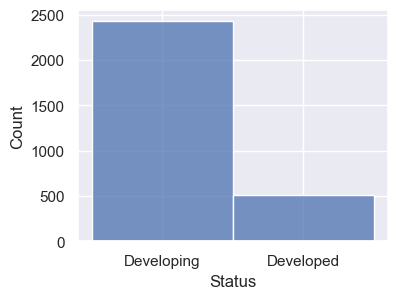

In [23]:
plt.figure(figsize=(4,3))
sns.histplot(x='Status',data=dados)

---
## Limpeza dos Dados

In [24]:
# Total de linhas por coluna | Presença de Valores nulos

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2938 non-null   object 
 1   Year                  2938 non-null   int64  
 2   Status                2938 non-null   object 
 3   Life_expectancy       2928 non-null   float64
 4   Adult_mortality       2928 non-null   float64
 5   Infant_deaths         2938 non-null   int64  
 6   Alcohol               2744 non-null   float64
 7   Hepatitis_b           2385 non-null   float64
 8   Measles               2938 non-null   int64  
 9   Bmi                   2904 non-null   float64
 10  Polio                 2919 non-null   float64
 11  Total_expenditure     2712 non-null   float64
 12  Diphtheria            2919 non-null   float64
 13  Hiv/aids              2938 non-null   float64
 14  Gdp                   2490 non-null   float64
 15  Population           

#### Detectando Valores Ausentes

In [25]:
# Extraindo o total de valores nulos por coluna

dados.isna().sum().sort_values(ascending=False)

Population              652
Hepatitis_b             553
Gdp                     448
Total_expenditure       226
Alcohol                 194
Schooling               163
Bmi                      34
Thinness_5-9_years       34
Thinness__1-19_years     34
Diphtheria               19
Polio                    19
Adult_mortality          10
Life_expectancy          10
Country                   0
Year                      0
Status                    0
Infant_deaths             0
Measles                   0
Hiv/aids                  0
dtype: int64

In [26]:
# Percentual de valores ausentes por coluna

dados.isna().mean().sort_values(ascending=False) * 100

Population              22.191967
Hepatitis_b             18.822328
Gdp                     15.248468
Total_expenditure        7.692308
Alcohol                  6.603131
Schooling                5.547992
Bmi                      1.157250
Thinness_5-9_years       1.157250
Thinness__1-19_years     1.157250
Diphtheria               0.646698
Polio                    0.646698
Adult_mortality          0.340368
Life_expectancy          0.340368
Country                  0.000000
Year                     0.000000
Status                   0.000000
Infant_deaths            0.000000
Measles                  0.000000
Hiv/aids                 0.000000
dtype: float64

**Primeiro devemos tratar os ***`Valores Outliers`*** antes de tratar os valores ausentes**

## Detectando Valores Outliers

Vamos analisar as variaveis que tem o maior percentual de valores ausentes

#### Selecionando as variaveis:

In [27]:
# Variaveis com MAIS DE 5% de valores ausentes

atributos = ['Population',
             'Hepatitis_b',
             'Gdp',
             'Total_expenditure',
             'Alcohol',
             'Schooling']

In [28]:
# Criando um novo dataframe para vizualização

novo_df = dados[atributos]

novo_df.head()

,Population,Hepatitis_b,Gdp,Total_expenditure,Alcohol,Schooling
0,33736494.0,65.0,584.259210,8.16,0.01,10.1
1,327582.0,62.0,612.696514,8.18,0.01,10.0
2,31731688.0,64.0,631.744976,8.13,0.01,9.9
3,3696958.0,67.0,669.959000,8.52,0.01,9.8
4,2978599.0,68.0,63.537231,7.87,0.01,9.5


### Metodo IQR

In [29]:
# Identificação de outliers atraves do metodo IQR

Q1 = novo_df.quantile(0.25)
Q3 = novo_df.quantile(0.75)
IQR = Q3 - Q1

#### definindo o limite para outliers para vizualização

In [30]:
# Definindo os outliers e retornando o total [Q1 - 1.5 * IQR e Q3 + 1.5 * IQR] = Dados 1.5 acima de Q3 ou abaixo de Q1 são outliers

outliers = ((novo_df < (Q1 - 1.5*IQR)) | (novo_df > (Q3 + 1.5*IQR))).sum()

#### Contagem de outliers

In [31]:
# Total dos outiliers em cada variavel

outliers

Population           294
Hepatitis_b          254
Gdp                  365
Total_expenditure     32
Alcohol                0
Schooling             44
dtype: int64

`A variável Alcohol não posue outliers`

#### Dataframe com percentual de outliers nas variaveis

In [32]:
# Criando o Dataframe

outlier_percentual = pd.DataFrame({'Outliers': outliers, 'Percentual': (outliers / len(novo_df)) * 100})

In [33]:
# Retornando os outliers quando o valor for maior do que zero

outlier_percentual[outlier_percentual['Outliers'] > 0]

,Outliers,Percentual
Population,294,10.006807
Hepatitis_b,254,8.645337
Gdp,365,12.423417
Total_expenditure,32,1.089176
Schooling,44,1.497617


## Tratamento de outliers com **Winsorization**

*Após um trabalho de vizualização dos outliers, nós iremos tratar os valores com o metodo de Winsorization*

In [34]:
for coluna in atributos:
    
    Q1 = dados[coluna].quantile(0.25) # Cálculo do primeiro quartil - 25% 
    Q3 = dados[coluna].quantile(0.75) # Cálculo do terceiro quartil - 75% 
    IQR = Q3 - Q1 # Cálculo do IQR

    # Limites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    dados[coluna] = dados[coluna].clip(limite_inferior, limite_superior) #clip() Limitar os valores dentro de um intervalo

In [35]:
# Vizualizando o resultado

Q1 = dados[atributos].quantile(0.25)
Q3 = dados[atributos].quantile(0.75)
IQR = Q3 - Q1

outliers_restantes = ((dados[atributos] < (Q1 - 1.5*IQR)) | (dados[atributos] > (Q3 + 1.5*IQR))).sum()

outliers_restantes

Population           0
Hepatitis_b          0
Gdp                  0
Total_expenditure    0
Alcohol              0
Schooling            0
dtype: int64

---
## Tratamento de valores ausentes:

#### 📉 `Regra prática usada em projetos` 📉
% de valores ausentes	| Estratégia comum
------------------------|-------------------
< 1%, 2%	| remover linhas (dropna)
2% – 5%	| remover linhas ou imputar
5% – 20%	| imputação (mediana, KNN)
Maior 30%	|remover variável

Remover linhas com menos de 1% ou até 2% de NaN geralmente não afeta o modelo e deixa o dataset mais limpo.


In [36]:
# Visualizando uma amostra dos dados

dados.head()

,Country,Year,Status,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Hepatitis_b,Measles,Bmi,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,6.0,8.16,65.0,0.1,584.259210,1.825721e+07,17.2,17.3,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,3.275820e+05,17.5,17.5,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,62.0,8.13,64.0,0.1,631.744976,1.825721e+07,17.7,17.7,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3.696958e+06,17.9,18.0,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2.978599e+06,18.2,18.2,9.5


In [37]:
# Percentual de valores ausentes por coluna

dados.isna().mean().sort_values(ascending=False) * 100

Population              22.191967
Hepatitis_b             18.822328
Gdp                     15.248468
Total_expenditure        7.692308
Alcohol                  6.603131
Schooling                5.547992
Bmi                      1.157250
Thinness_5-9_years       1.157250
Thinness__1-19_years     1.157250
Diphtheria               0.646698
Polio                    0.646698
Adult_mortality          0.340368
Life_expectancy          0.340368
Country                  0.000000
Year                     0.000000
Status                   0.000000
Infant_deaths            0.000000
Measles                  0.000000
Hiv/aids                 0.000000
dtype: float64

## Metodo KNN Imputer
**Ele usa os valores das outras variáveis para estimar os valores ausentes.**

✔ Mais usado em ciência de dados

✔ preserva relações entre variáveis

#### Para as vriaveis:

* Population	22%
* Hepatitis_b	18%
* Gdp	15%

#### Padronizando os dados
`Sempre devemos padronizar os dados para usar o KNN Imputer, depois voltaremos com os valores originais após tratar os NaN`

In [38]:
colunas_knn = ['Population','Hepatitis_b','Gdp']

In [39]:
scaler = StandardScaler()

dados_scaled = scaler.fit_transform(dados[colunas_knn])

*`Agora todos os valores estão normalizados (média = 0, desvio = 1).`*

#### Metodo KNN Imputer

In [40]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

dados_imputados = imputer.fit_transform(dados_scaled)

`n_neighbors=5m`

Define quantos vizinhos mais próximos serão usados para estimar um valor ausente.

Depois ele faz normalmente a média desses 5 valores.

In [41]:
# Voltando para escala original | voltando aos valores originais

dados_imputados = scaler.inverse_transform(dados_imputados)

In [42]:
# colocar de volta no dataframe

dados[colunas_knn] = dados_imputados

## Colunas entre 5% e 10% iremos preencher com a mediana

* Total_expenditure	7.6%
* Alcohol	6.6%
* Schooling

In [43]:
for col in ['Total_expenditure','Alcohol','Schooling']:
    dados[col].fillna(dados[col].median(), inplace=True)

## Colunas com menos de 2%

**Faremos o Drop de Linhas**

`Variável/ Bmi/ Thinness_5-9_years/ Thinness__1-19_years/ Diphtheria/ Polio/ Adult_mortality/ Life_expectancy`

In [44]:
# Selecioando as colunas

# colunas = ['Bmi','Thinness_5-9_years','Thinness__1-19_years','Diphtheria','Polio','Adult_mortality','Life_expectancy']

# Tratando os dados

# dados = dados.dropna(subset=colunas)

In [45]:
# Ou podemos fazer diretamente no dataset

dados = dados.dropna()

#### Resultado:

In [46]:
# Percentual de valores ausentes por coluna

dados.isna().mean().sort_values(ascending=False) * 100

Country                 0.0
Year                    0.0
Status                  0.0
Life_expectancy         0.0
Adult_mortality         0.0
Infant_deaths           0.0
Alcohol                 0.0
Hepatitis_b             0.0
Measles                 0.0
Bmi                     0.0
Polio                   0.0
Total_expenditure       0.0
Diphtheria              0.0
Hiv/aids                0.0
Gdp                     0.0
Population              0.0
Thinness__1-19_years    0.0
Thinness_5-9_years      0.0
Schooling               0.0
dtype: float64

---
## Engenharia de Atributos

**As variaveis Alcohol e Bmi tem uma relação direta e natural. Vamos criar uma nov variavel chamada Life_style com a combinação dessas duas variaveis**

In [47]:
# Amostra dos dados

dados.head()

,Country,Year,Status,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Hepatitis_b,Measles,Bmi,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,6.0,8.16,65.0,0.1,584.259210,1.825721e+07,17.2,17.3,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,3.275820e+05,17.5,17.5,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,62.0,8.13,64.0,0.1,631.744976,1.825721e+07,17.7,17.7,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3.696958e+06,17.9,18.0,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2.978599e+06,18.2,18.2,9.5


In [48]:
# Visualizando o significado da variavel

df_dict['bmi']

'Índice médio de massa corporal da população adulta.'

In [49]:
# Criando a nova variavel

dados['Life_style'] = 0
dados.Life_style = dados['Bmi'] * dados['Alcohol']

In [50]:
dados.head()

,Country,Year,Status,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Hepatitis_b,Measles,Bmi,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Schooling,Life_style
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,6.0,8.16,65.0,0.1,584.259210,1.825721e+07,17.2,17.3,10.1,0.191
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,3.275820e+05,17.5,17.5,10.0,0.186
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,62.0,8.13,64.0,0.1,631.744976,1.825721e+07,17.7,17.7,9.9,0.181
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3.696958e+06,17.9,18.0,9.8,0.176
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2.978599e+06,18.2,18.2,9.5,0.172


In [51]:
# Resumo estatistico da variavel Life_style

dados['Life_style'].describe()

count    2888.000000
mean      200.930781
std       225.810676
min         0.014000
25%        20.301000
50%       102.590000
75%       319.302500
max      1036.869000
Name: Life_style, dtype: float64

In [52]:
# Verificando valores ausentes

valores_ausentes = dados.isna().sum().sort_values(ascending = False)

valores_ausentes

Country                 0
Year                    0
Status                  0
Life_expectancy         0
Adult_mortality         0
Infant_deaths           0
Alcohol                 0
Hepatitis_b             0
Measles                 0
Bmi                     0
Polio                   0
Total_expenditure       0
Diphtheria              0
Hiv/aids                0
Gdp                     0
Population              0
Thinness__1-19_years    0
Thinness_5-9_years      0
Schooling               0
Life_style              0
dtype: int64

In [53]:
# Verificaando o tipo dos dados

dados.dtypes
#dados.info()

Country                  object
Year                      int64
Status                   object
Life_expectancy         float64
Adult_mortality         float64
Infant_deaths             int64
Alcohol                 float64
Hepatitis_b             float64
Measles                   int64
Bmi                     float64
Polio                   float64
Total_expenditure       float64
Diphtheria              float64
Hiv/aids                float64
Gdp                     float64
Population              float64
Thinness__1-19_years    float64
Thinness_5-9_years      float64
Schooling               float64
Life_style              float64
dtype: object

## Analise de correlação para verificar multicolinearidade

Queremos que as variáveis preditoras tenham uma alta correlação com a variável alvo, mas não queremos que as variáveis preditoras tenham alta correlação entre si. `Se houver alta correlação entre as variáveis preditoras isso é chamado de multicolinearidade e fere uma das suposições da regressão.`

A correlação é uma medida da relação entre as variáveis. O coeficiente de correlação é um valor de -1 a +1, sendo:

**-1 indica alta correlação negativa.**

**+1 indica ata correlação positiva. (Observação: há um erro de digitação na imagem original, onde se lê "ata" em vez de "alta").**

**0 indica que não há correlação.**

`Correlação não implica causalidade.` ***Por exemplo:*** Sempre que aumenta o consumo de sorvete aumenta a presença de tubarões na praia. Provavelmente ambos os eventos ocorrem no verão e estão correlacionados, mas isso não significa que um evento causa o outro. Para afirmar isso teríamos que fazer uma análise de causalidade.

In [54]:
# Corelação das variaveis numericas

dados_num = dados.select_dtypes(include='number').corr()
# dados.corr(numeric_only=True)

dados_num

,Year,Life_expectancy,Adult_mortality,Infant_deaths,Alcohol,Hepatitis_b,Measles,Bmi,Polio,Total_expenditure,Diphtheria,Hiv/aids,Gdp,Population,Thinness__1-19_years,Thinness_5-9_years,Schooling,Life_style
Year,1.000000,0.170772,-0.080136,-0.037310,-0.070084,0.107018,-0.083198,0.105360,0.096300,0.070464,0.136667,-0.141273,0.125985,0.044917,-0.044713,-0.047784,0.203134,-0.017033
Life_expectancy,0.170772,1.000000,-0.693189,-0.197408,0.390840,0.282358,-0.160525,0.567055,0.464166,0.208806,0.478194,-0.560382,0.525959,-0.063749,-0.476342,-0.470744,0.736173,0.490722
Adult_mortality,-0.080136,-0.693189,1.000000,0.078712,-0.189009,-0.195345,0.032587,-0.386460,-0.271549,-0.107110,-0.272017,0.526784,-0.334002,0.061310,0.302124,0.307695,-0.435458,-0.277100
Infant_deaths,-0.037310,-0.197408,0.078712,1.000000,-0.113844,-0.229009,0.501103,-0.227574,-0.171630,-0.130244,-0.175967,0.025280,-0.153835,0.245450,0.466297,0.471925,-0.206517,-0.153435
Alcohol,-0.070084,0.390840,-0.189009,-0.113844,1.000000,0.123869,-0.051163,0.324741,0.213747,0.309645,0.214340,-0.049157,0.414793,-0.031066,-0.420968,-0.409823,0.518338,0.872957
Hepatitis_b,0.107018,0.282358,-0.195345,-0.229009,0.123869,1.000000,-0.120052,0.181577,0.456807,0.100938,0.513941,-0.122373,0.236329,-0.122078,-0.167714,-0.177544,0.262247,0.141714
Measles,-0.083198,-0.160525,0.032587,0.501103,-0.051163,-0.120052,1.000000,-0.176145,-0.137803,-0.106222,-0.143337,0.031004,-0.102905,0.102827,0.224876,0.221120,-0.134313,-0.106561
Bmi,0.105360,0.567055,-0.386460,-0.227574,0.324741,0.181577,-0.176145,1.000000,0.287579,0.223618,0.286077,-0.243839,0.379541,-0.070453,-0.529737,-0.536757,0.555924,0.621608
Polio,0.096300,0.464166,-0.271549,-0.171630,0.213747,0.456807,-0.137803,0.287579,1.000000,0.136943,0.668335,-0.160840,0.274662,-0.056816,-0.222790,-0.223568,0.402281,0.254423
Total_expenditure,0.070464,0.208806,-0.107110,-0.130244,0.309645,0.100938,-0.106222,0.223618,0.136943,1.000000,0.151173,0.004673,0.141497,-0.084015,-0.268088,-0.274850,0.256814,0.323890


In [55]:
def filtrar_visualizar_correlacao(df, threshold, drop_column=None):

    # Matriz de correlação
    corr = df.corr()

    # Filtrando correlações acima do limite e removendo a diagonal (1.0) e a correlação da variavel com ela mesma
    # abs(corr) Transforma todos os valores em valor absoluto. Remove o sinal negativo (-)
    # >= threshold Seleciona apenas correlações acima de um limite threshold que por padrão é 0.3
    # (corr != 1.0) Remove a correlação perfeita. Correlação da variavel com ela mesma:
    corr = corr[(corr.abs() >= threshold) & (corr != 1.0)]

    # Remove linhas e colunas vazias
    # dropna(how='all') Remove linhas onde todos os valores são NaN.
    # dropna(axis=1, how='all') Remove colunas onde todos os valores são NaN.
    # Obs: axis=0	operar nas linhas vertical| axis=1	operar nas colunas horizontal
    corr = corr.dropna(how='all').dropna(axis=1, how='all')

    # Remove a coluna se for informada | pode se removida da função!
    # Se drop_column for Verdadeiro/tiver algum valor (não for None), então drop nas linha e na coluna repassada.
    # index=drop_column, columns=drop_column Remove a linha e a coluna com esse mesmo nome
    if drop_column:
        corr = corr.drop(index=drop_column, columns=drop_column, errors='ignore')

    # Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.show()

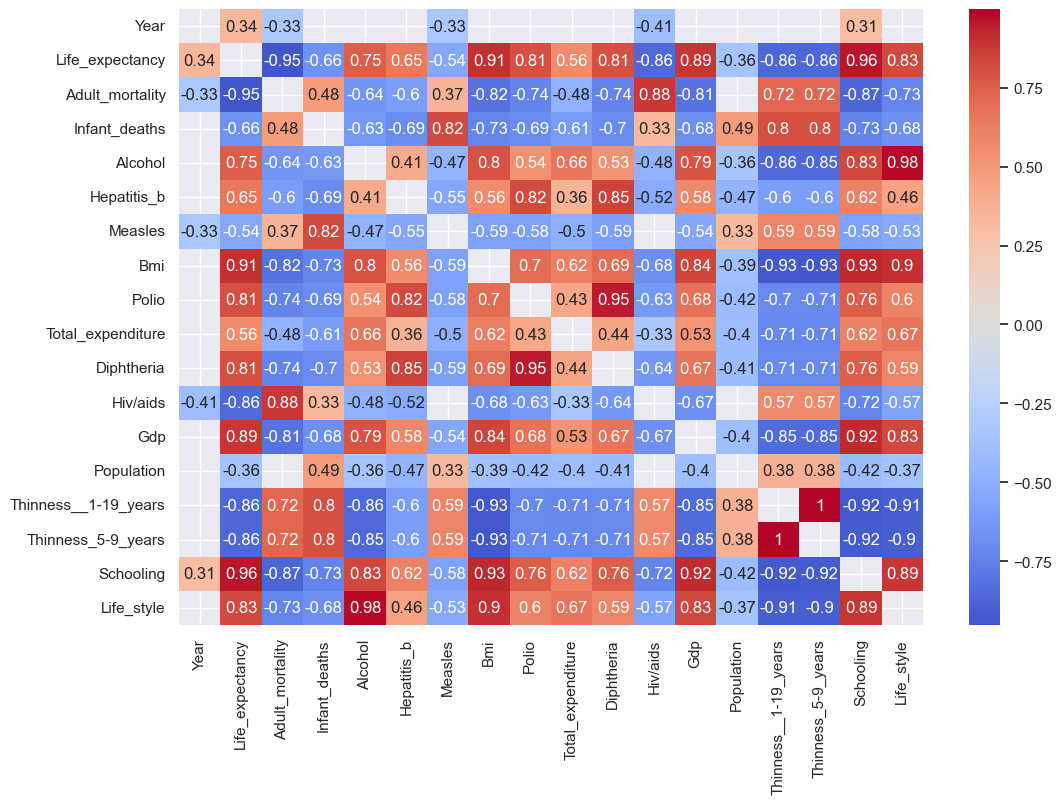

In [56]:
# Executando a Função

filtrar_visualizar_correlacao(dados_num, 0.3)

#### Variaveis preditoras com maior correlação com a variavel alvo:

* `Variavel Alvo: Life_expectancy`
* Adult_mortality
* Alcohol
* Bmi
* Polio
* Diphtheria
* Hiv/aids
* Gdp
* Thinness__1-19_years
* Thinness_5-9_years
* Schooling
* Life_style

***Agora podemos checar uma das supsições da regressão linear e identificar possiveis probllemas de multicolinearidade (Alta correlação entre as variaveis preditoras). Vamos considerar 0.65 como uma marca de corte.***

In [57]:
dados_novo = dados[['Life_expectancy', 'Adult_mortality', 'Alcohol', 'Bmi', 'Polio', 
                    'Diphtheria', 'Hiv/aids', 'Gdp', 'Thinness__1-19_years', 
                    'Thinness_5-9_years', 'Schooling', 'Life_style']]

#### Verificando a correlação entre as variaveis:

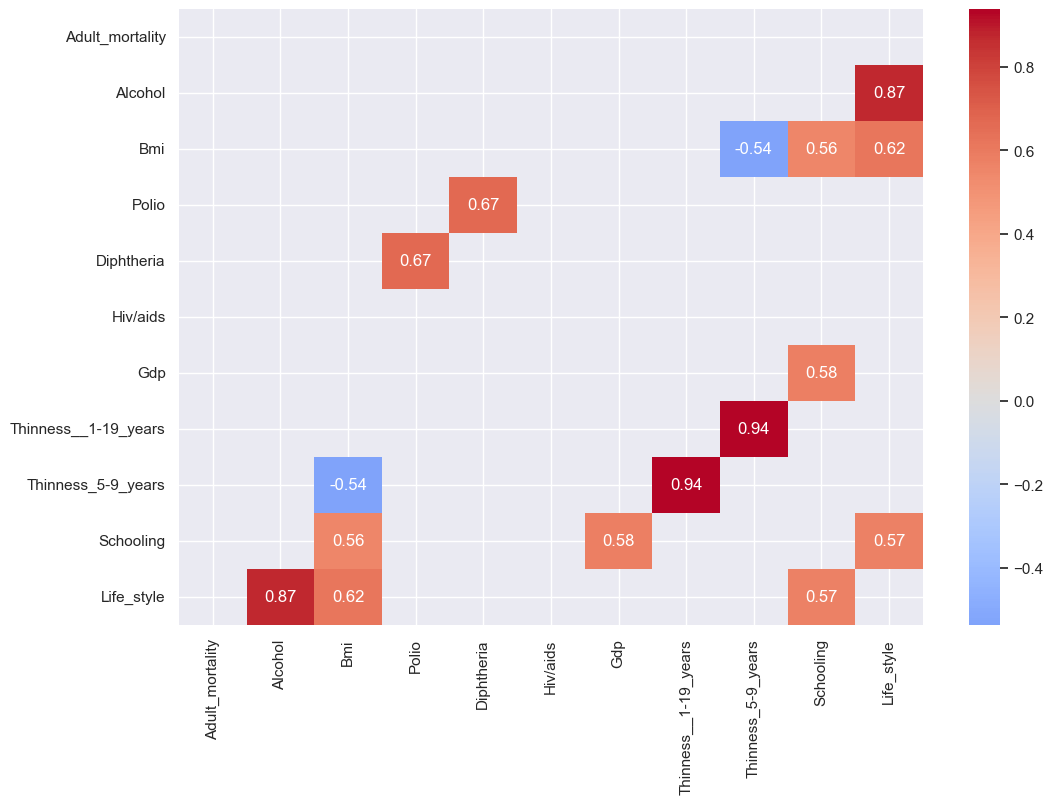

In [58]:
filtrar_visualizar_correlacao(dados_novo, 0.53, 'Life_expectancy')

## Decisão:

**Multicolinearidade**

* Manteremos a variavel Thinness__1-19_years, pois elas explicam a mesma coisa, a primeria, comtempla a informação da variavel Thinness_5-9_years, que será emovida, a correlção das duas variaveis com a variavel alvo é de -0.86;

* Taxas de vacinação: Polio e Diphtheria: 0.81, 0.79 respectivamente, vamos deletar a variavel de menor correlação com a variavel alvo que será Diphtheria

* Bmi 0.91 de corr com a variavel alvo: Ela tem uma forte correlação com Thinness_5-9_years, porém ja resolvemos a variavel. Ela tambem tem uma forte correlação com Schooling que é 0.96 de correlação com a variavel alvo, então removeremos a variavel Bmi

* Removemos tambem a variavel Alcohol (0.75 de corr com a variavel alvo) que tem forte correlação com Life_style (0.83 de corr com a variavel alvo)



* **Primeiro filtro - Correlação com a Variável Alvo**

As variaveis atendem o critério, Elas são as variaveis com maior correlação com a variavel alvo

* **Segundo Filtro - Multicolinearidade**

removemos as variaveis **Thinness_5-9_years**, **Diphtheria**, **Bmi**, **Alcohol**.

In [59]:
novo_df_final = dados[['Life_expectancy', 'Adult_mortality',
                    'Diphtheria', 'Hiv/aids', 'Gdp', 'Thinness__1-19_years', 
                    'Schooling', 'Life_style']]

#### Variaveis com maior correlação:

In [60]:
novo_df_final

,Life_expectancy,Adult_mortality,Diphtheria,Hiv/aids,Gdp,Thinness__1-19_years,Schooling,Life_style
0,65.0,263.0,65.0,0.1,584.259210,17.2,10.1,0.191
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
2,59.9,268.0,64.0,0.1,631.744976,17.7,9.9,0.181
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
...,...,...,...,...,...,...,...,...
2933,44.3,723.0,65.0,33.6,454.366654,9.4,9.2,118.156
2934,44.5,715.0,68.0,36.7,453.351155,9.8,9.5,108.402
2935,44.8,73.0,71.0,39.8,57.348340,1.2,10.0,116.509
2936,45.3,686.0,75.0,42.1,548.587312,1.6,9.8,44.548


In [61]:
# Verificando presença de valores ausentes

novo_df_final.isna().sum().sort_values(ascending=False)

Life_expectancy         0
Adult_mortality         0
Diphtheria              0
Hiv/aids                0
Gdp                     0
Thinness__1-19_years    0
Schooling               0
Life_style              0
dtype: int64

In [62]:
novo_df_final.dtypes

Life_expectancy         float64
Adult_mortality         float64
Diphtheria              float64
Hiv/aids                float64
Gdp                     float64
Thinness__1-19_years    float64
Schooling               float64
Life_style              float64
dtype: object

In [63]:
novo_df_final.shape

(2888, 8)

# Fim